## Model Price vs. Spare Capacity Metric

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

GEN_PATH = '../../01_data/2_cleaned/generation/hourly_solar_wind_generation_2020_2025.parquet'
LOAD_PATH = '../../01_data/2_cleaned/load/total_load_20201231_20260526.csv'
CAPACITY_PATH = '../../01_data/2_cleaned/generation/ERCOT nonRE capacity 2020-2025.csv'
PRICE_PATH = '../../01_data/2_cleaned/rtm_price/rtm_price_aggregated_2021_2025.csv'
NG_PATH = '../../01_data/3_analysis/ng_price/ng_prices_monthly.csv'
TEMP_PATH = '../../01_data/2_cleaned/weather/Texas_hourly_temp_2021_2025.csv'

OUT_DIR = Path('../../01_data/3_analysis/price incentive metrics')

In [2]:
# import datasets
df_gen = pd.read_parquet(GEN_PATH)
df_gen['datetime'] = pd.to_datetime(df_gen['datetime'])
df_gen.head()

,datetime,renewable_gen
0,2020-01-01 01:00:00,12832.85
1,2020-01-01 02:00:00,13328.73
2,2020-01-01 03:00:00,13920.06
3,2020-01-01 04:00:00,14443.91
4,2020-01-01 05:00:00,14713.70


In [3]:
df_load = pd.read_csv(LOAD_PATH)
df_load['datetime'] = pd.to_datetime(df_load['datetime'])
df_load.head()

,datetime,total_load
0,2020-12-31 01:00:00,39174.39
1,2020-12-31 02:00:00,38284.84
2,2020-12-31 03:00:00,37776.69
3,2020-12-31 04:00:00,37781.84
4,2020-12-31 05:00:00,38455.69


In [4]:
df_capacity = pd.read_csv(CAPACITY_PATH)
df_total_cap = df_capacity.filter(['year', 'total_mw'])
df_total_cap = df_total_cap.rename(columns={'total_mw': 'non_re_capacity'})
df_total_cap['non_re_capacity'] = df_total_cap['non_re_capacity'].astype(int)
df_total_cap

,year,non_re_capacity
0,2020,65518
1,2021,66390
2,2022,67023
3,2023,68028
4,2024,68766
5,2025,68624


In [5]:
df_price = pd.read_csv(PRICE_PATH)
df_price = df_price.filter(['date_time', 'avg_rtm_price'])
df_price = df_price.rename(columns={'date_time': 'datetime', 'avg_rtm_price' : 'rtm_price'})
df_price['datetime'] = pd.to_datetime(df_price['datetime'])
df_price.describe()

,datetime,rtm_price
count,43315,43315.000000
mean,2023-07-02 13:27:46.729770,66.584313
min,2021-01-01 01:00:00,-2.656667
25%,2022-04-03 07:30:00,19.183333
50%,2023-07-05 13:00:00,27.560000
75%,2024-09-29 18:30:00,43.636000
max,2025-12-28 00:00:00,9001.180667
std,NaN,418.440833


In [6]:
df_ng = pd.read_csv(NG_PATH)
df_ng = df_ng[(df_ng['date']>= '2021-01-01') & (df_ng['date']<= '2025-12-01')]
df_ng['date'] = pd.to_datetime(df_ng['date'])
df_ng['month'] = df_ng['date'].dt.month
df_ng['year'] = df_ng['date'].dt.year

df_ng.head()

,date,henry_hub,citygate,elec_pwr,outlier_citygate,outlier_elec_pwr,month,year
227,2021-01-01,2.712632,2.909441,2.793834,False,False,1,2021
228,2021-02-01,5.353684,39.181118,59.614644,True,True,2,2021
229,2021-03-01,2.618261,4.393064,2.947977,False,False,3,2021
230,2021-04-01,2.662857,3.554913,3.131021,False,False,4,2021
231,2021-05-01,2.912500,3.429672,3.294798,False,False,5,2021


In [7]:
df_temp = pd.read_csv(TEMP_PATH)
df_temp

,datetime,tx_temp
0,2025-12-31 23:00:00,63.0
1,2025-12-31 22:00:00,64.0
2,2025-12-31 21:00:00,66.0
3,2025-12-31 20:00:00,65.0
4,2025-12-31 19:00:00,61.0
...,...,...
43819,2021-01-01 04:00:00,36.0
43820,2021-01-01 03:00:00,36.0
43821,2021-01-01 02:00:00,38.0
43822,2021-01-01 01:00:00,39.0


### Metric 1: spare capacity calculation
1. exclude uri points ()
2. metric1: evaluates spare capacity; 
    - closer to 1: load >> capacity limit
    - heat wave drives up load or data center demand increase

In [8]:
import duckdb
con = duckdb.connect()
df_metric = con.execute("""
   WITH Merged AS (
      SELECT
         g.datetime
         ,rtm_price
         ,renewable_gen
         ,total_load
         ,non_re_capacity
      FROM df_gen g
      INNER JOIN df_load l ON g.datetime = l.datetime
      LEFT JOIN df_total_cap c ON YEAR(g.datetime) = c.year
      JOIN df_price p ON g.datetime = p.datetime
      WHERE CAST(g.datetime AS DATE) <= '2021-02-13' OR CAST(g.datetime AS DATE) >= '2021-02-25'                 
      )
   
   SELECT
         datetime
         ,YEAR(datetime) AS year
         ,rtm_price
         ,(total_load - renewable_gen)/non_re_capacity AS metric1
   FROM Merged
   ORDER BY datetime;
""").fetchdf()

df_metric

,datetime,year,rtm_price,metric1
0,2021-01-01 01:00:00,2021,18.714000,0.447794
1,2021-01-01 02:00:00,2021,18.107333,0.437193
2,2021-01-01 03:00:00,2021,17.570000,0.434211
3,2021-01-01 04:00:00,2021,17.670667,0.449278
4,2021-01-01 05:00:00,2021,17.792000,0.470151
...,...,...,...,...
43025,2025-12-27 20:00:00,2025,17.682000,0.393060
43026,2025-12-27 21:00:00,2025,15.002667,0.374186
43027,2025-12-27 22:00:00,2025,13.227333,0.369187
43028,2025-12-27 23:00:00,2025,14.328667,0.349536


### Local Regression by year slices

In [10]:
import statsmodels.api as sm
def lowess_fit(x, y, color, label):
    
    # 2. Apply LOWESS local regression
    # frac: the fraction of data used when estimating each y-value (controls smoothing)
    lowess_fit = sm.nonparametric.lowess(y, x, frac=0.1)

    # Extract sorted x and predicted y values
    x_smooth = lowess_fit[:, 0]
    y_smooth = lowess_fit[:, 1]

    # plot
    plt.scatter(x, y, color='lightgray')
    plt.plot(x_smooth, y_smooth, color=color, linewidth=2, label=f"{label} LOWESS Fit")
    plt.legend()

/Users/zyliazhang/Git/ERCOT-Research/.venv/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


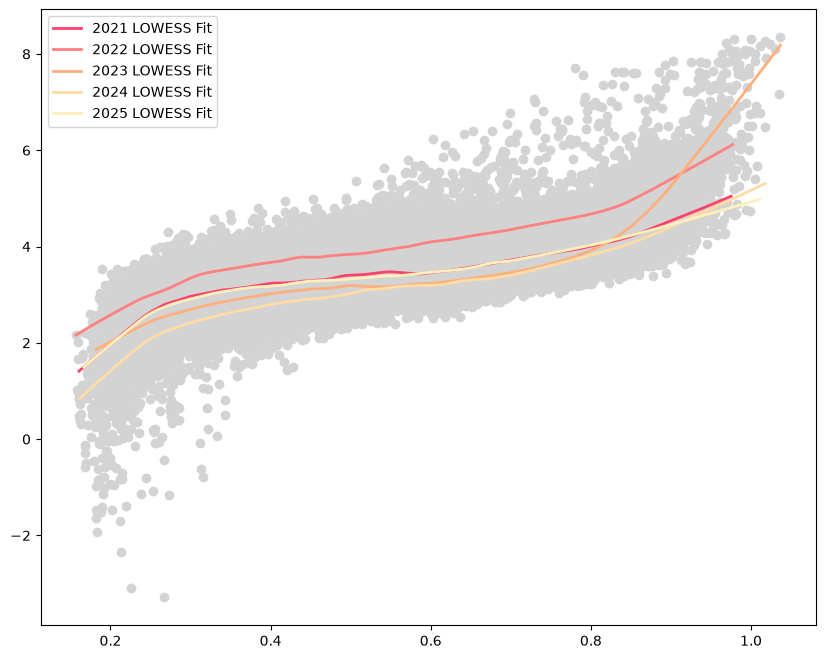

In [11]:
fig, ax = plt.subplots(figsize=(10, 8))
years = [2021, 2022, 2023, 2024, 2025]
colors = ['#FF416C', '#FF8080', '#FFAF7B', '#FFDCA6', '#FFEFBA']

for year, color in zip(years, colors):
    df_year = df_metric[df_metric['year'] == year]
    lowess_fit(df_year['metric1'], np.log(df_year['rtm_price']), color, year)

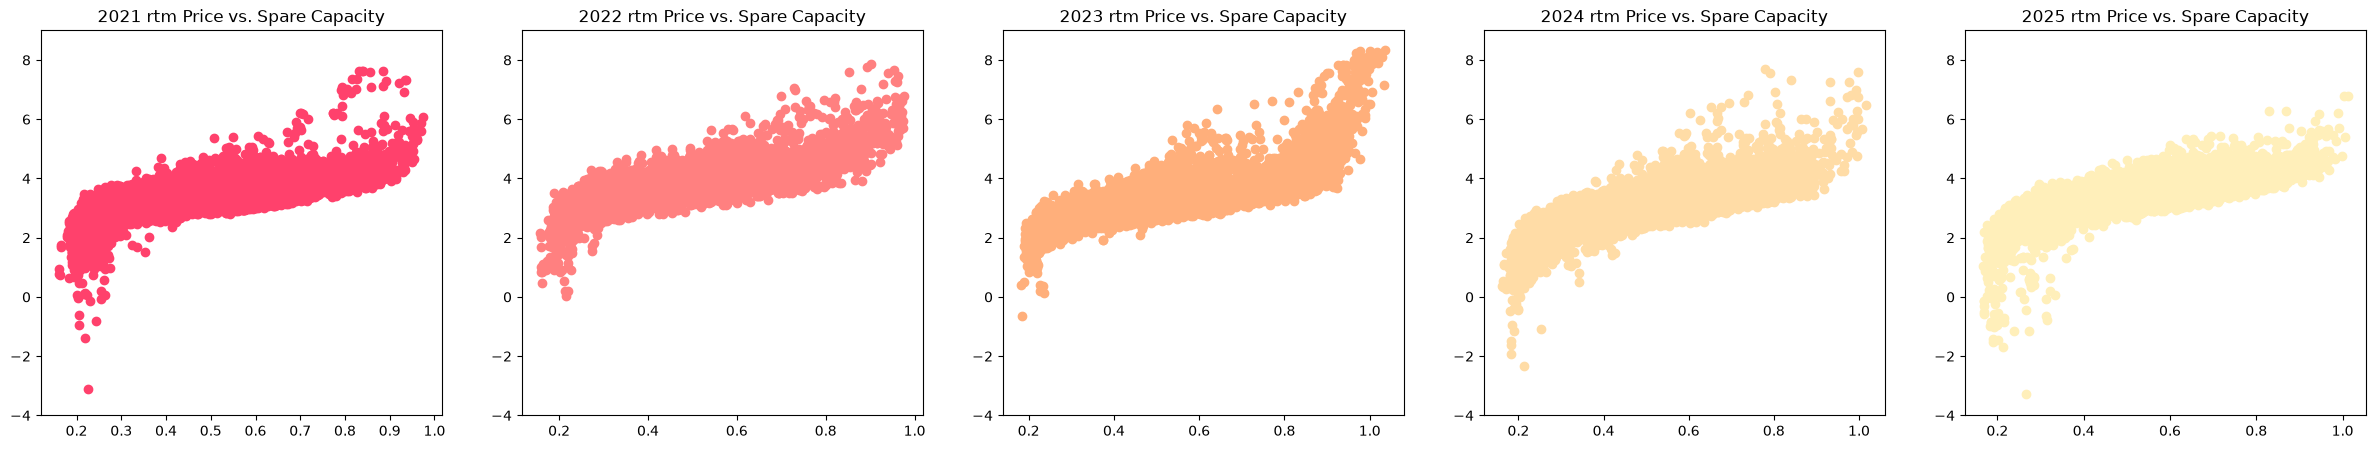

In [12]:
fig, axs = plt.subplots(1, 5, figsize=(30, 5))
for i, year in enumerate(years):
    df_year = df_metric[df_metric['year'] == year]
    axs[i].scatter(df_year['metric1'], np.log(df_year['rtm_price']), color=colors[i])
    axs[i].set_ylim(-4, 9)
    axs[i].set_title(f'{year} rtm Price vs. Spare Capacity')

### Slice by monthly timeseries

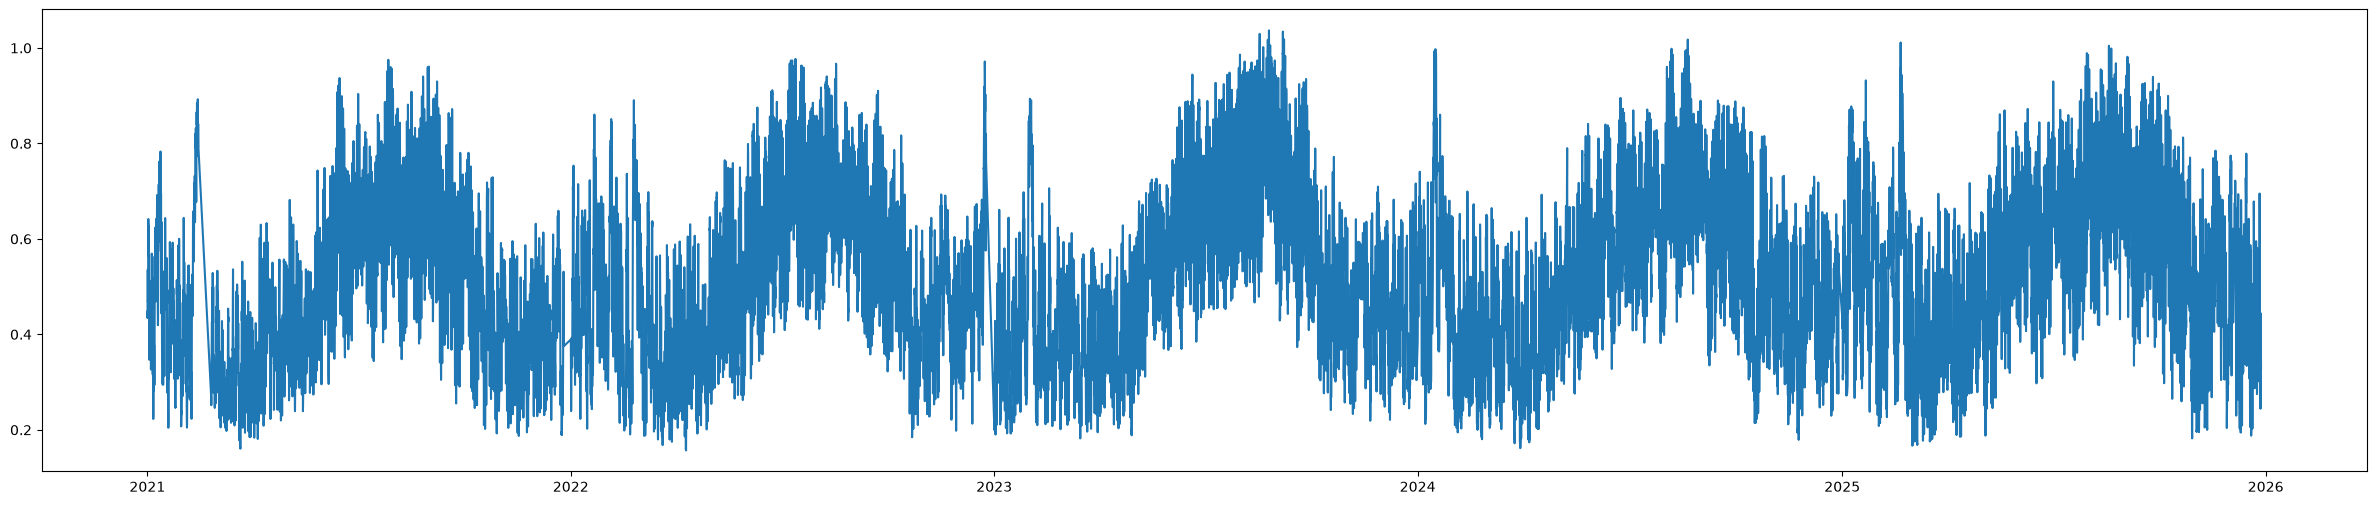

In [13]:
fig, ax = plt.subplots(figsize=(30, 6))
ax.plot(df_metric['datetime'] , df_metric['metric1'])

In [14]:
df_metric.groupby('year').mean()['metric1']

year
2021    0.484074
2022    0.511189
2023    0.515519
2024    0.506013
2025    0.518950
Name: metric1, dtype: float64

Text(0, 0.5, 'Spare Capacity')

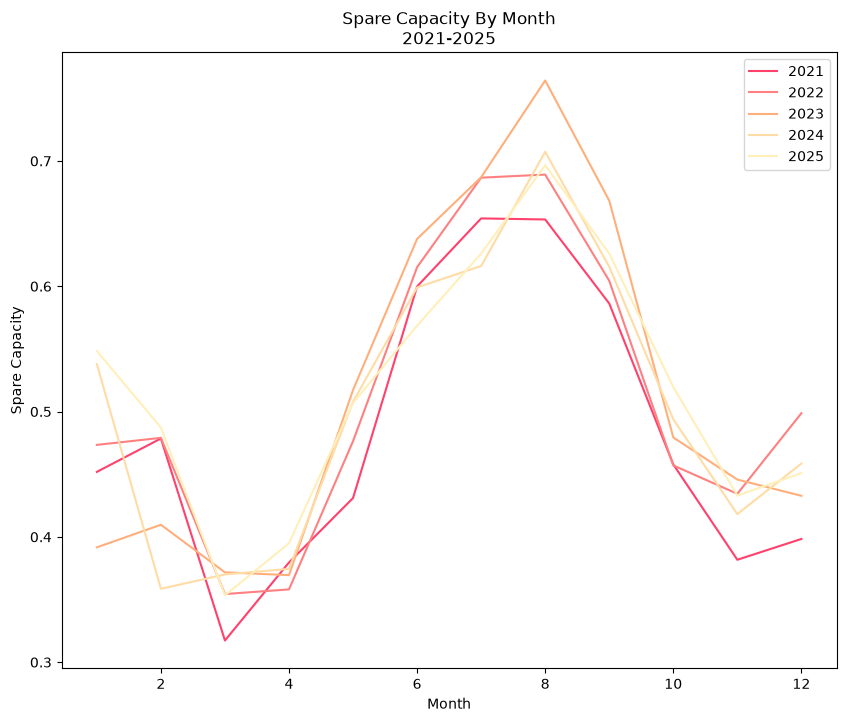

In [15]:
plt.figure(figsize=(10, 8))
df_month = df_metric.copy()
df_month['month'] = df_month['datetime'].dt.month

for year, color in zip(df_month['year'].unique(), colors):
    df = df_month[df_month['year']==year]
    df = df.groupby(df['datetime'].dt.month).mean()
    plt.plot(df['month'] , df['metric1'], color=color, label=year)
plt.legend()
plt.title('Spare Capacity By Month\n2021-2025')
plt.xlabel('Month')
plt.ylabel('Spare Capacity')

### Natural Gas color coding

In [16]:
df_metric_with_ng = con.execute("""
      SELECT 
         m.datetime
         ,rtm_price
         ,metric1 AS capacity
         ,citygate AS ng_price
      FROM df_metric m
         LEFT JOIN df_ng n ON n.month = MONTH(m.datetime)
                           AND n.year = m.year                         
      ORDER BY n.year, n.month;
""").fetchdf()

df_metric_with_ng

,datetime,rtm_price,capacity,ng_price
0,2021-01-01 01:00:00,18.714000,0.447794,2.909441
1,2021-01-01 02:00:00,18.107333,0.437193,2.909441
2,2021-01-01 03:00:00,17.570000,0.434211,2.909441
3,2021-01-01 04:00:00,17.670667,0.449278,2.909441
4,2021-01-01 05:00:00,17.792000,0.470151,2.909441
...,...,...,...,...
43025,2025-12-27 20:00:00,17.682000,0.393060,4.065511
43026,2025-12-27 21:00:00,15.002667,0.374186,4.065511
43027,2025-12-27 22:00:00,13.227333,0.369187,4.065511
43028,2025-12-27 23:00:00,14.328667,0.349536,4.065511


In [17]:
np.log(10)

np.float64(2.302585092994046)

/Users/zyliazhang/Git/ERCOT-Research/.venv/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


Text(0.5, 1.0, 'RTM Price (Log) vs. Spare Capacity colored by NG Price (Log)\n2021-2025')

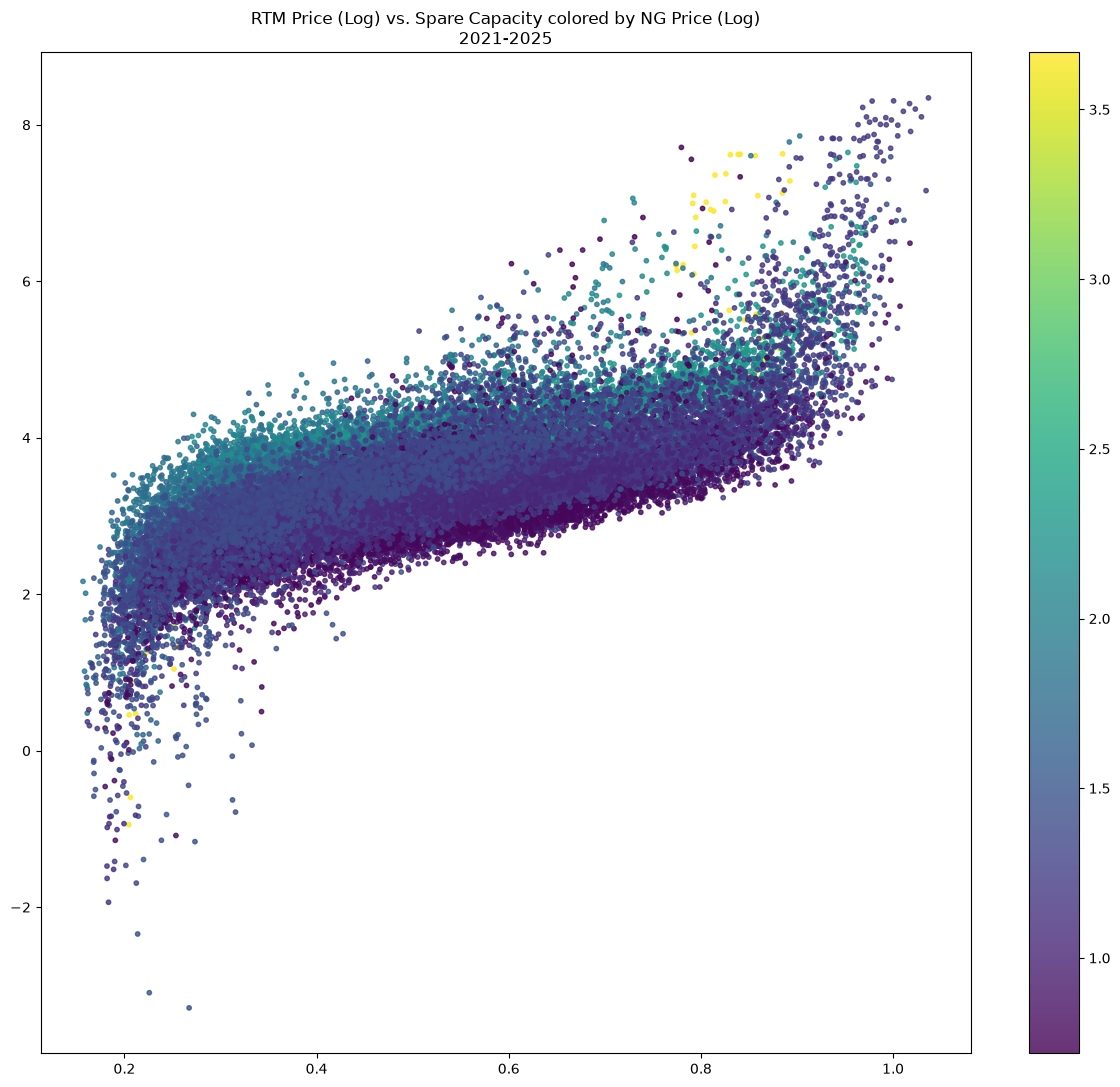

In [18]:
df = df_metric_with_ng.copy()
#df = df[df['ng_price'] > np.exp(1)**3]
plt.figure(figsize=(15, 13))
plt.scatter(df['capacity'], np.log(df['rtm_price']), c=np.log(df['ng_price']), alpha=0.8, s=10)
plt.colorbar()
plt.title('RTM Price (Log) vs. Spare Capacity colored by NG Price (Log)\n2021-2025')

/Users/zyliazhang/Git/ERCOT-Research/.venv/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


Text(0.5, 0, 'Spare Capacity Metric')

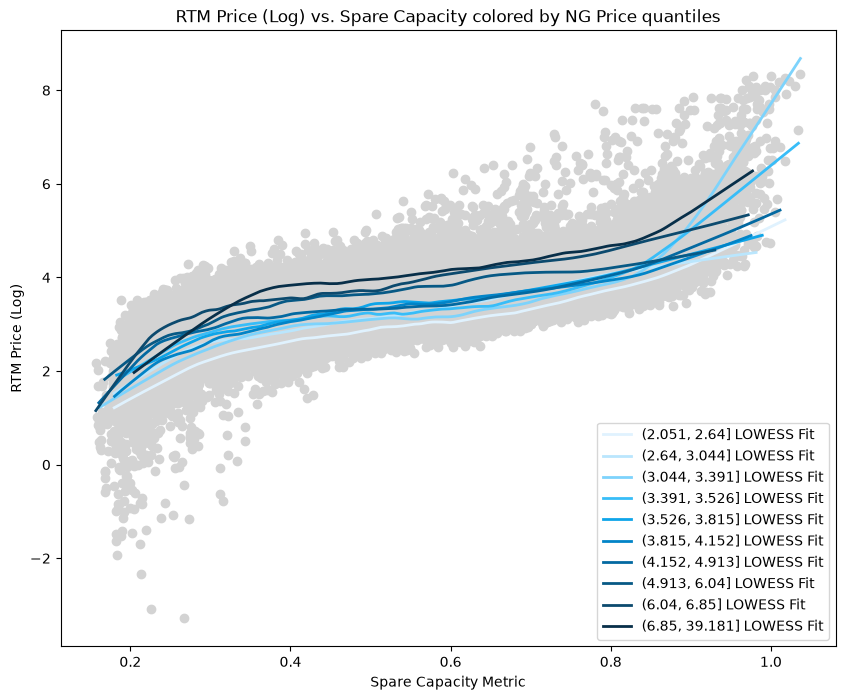

In [24]:
df = df_metric_with_ng.copy()
df = df.dropna()
df['ng_bins'] = pd.qcut(df['ng_price'], 10)
df_bins = df.sort_values('ng_bins')

fig, ax = plt.subplots(figsize=(10, 8))

colors10 = ['#E0F2FE', '#BAE6FD', '#7DD3FC', '#38BDF8', '#0EA5E9', '#0284C7', '#0369A1', '#075985', '#0C4A6E', '#082F49']

for bin, color in zip(df_bins['ng_bins'].unique(), colors10):
    df_bin = df_bins[df_bins['ng_bins'] == bin]
    lowess_fit(df_bin['capacity'], np.log(df_bin['rtm_price']), color, bin)

plt.title('RTM Price (Log) vs. Spare Capacity colored by NG Price quantiles')
plt.ylabel('RTM Price (Log)')
plt.xlabel('Spare Capacity Metric')

### Temp Color Coding

In [10]:
df_metric_with_temp = con.execute("""
      SELECT 
         m.datetime
         ,ABS(tx_temp - 65) AS degree_days
         ,rtm_price
         ,metric1 AS capacity
      FROM df_metric m
         LEFT JOIN df_temp t ON t.datetime = m.datetime                        
      ORDER BY m.datetime;
""").fetchdf()
df_metric_with_temp

,datetime,degree_days,rtm_price,capacity
0,2021-01-01 01:00:00,26.0,18.714000,0.447794
1,2021-01-01 02:00:00,27.0,18.107333,0.437193
2,2021-01-01 03:00:00,29.0,17.570000,0.434211
3,2021-01-01 04:00:00,29.0,17.670667,0.449278
4,2021-01-01 05:00:00,30.0,17.792000,0.470151
...,...,...,...,...
43025,2025-12-27 20:00:00,15.0,17.682000,0.393060
43026,2025-12-27 21:00:00,16.0,15.002667,0.374186
43027,2025-12-27 22:00:00,14.0,13.227333,0.369187
43028,2025-12-27 23:00:00,12.0,14.328667,0.349536


/Users/zyliazhang/Git/ERCOT-Research/.venv/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


Text(0.5, 1.0, 'RTM Price vs. Spare Capacity (colored by |Temp - 65|)\n2021-2025')

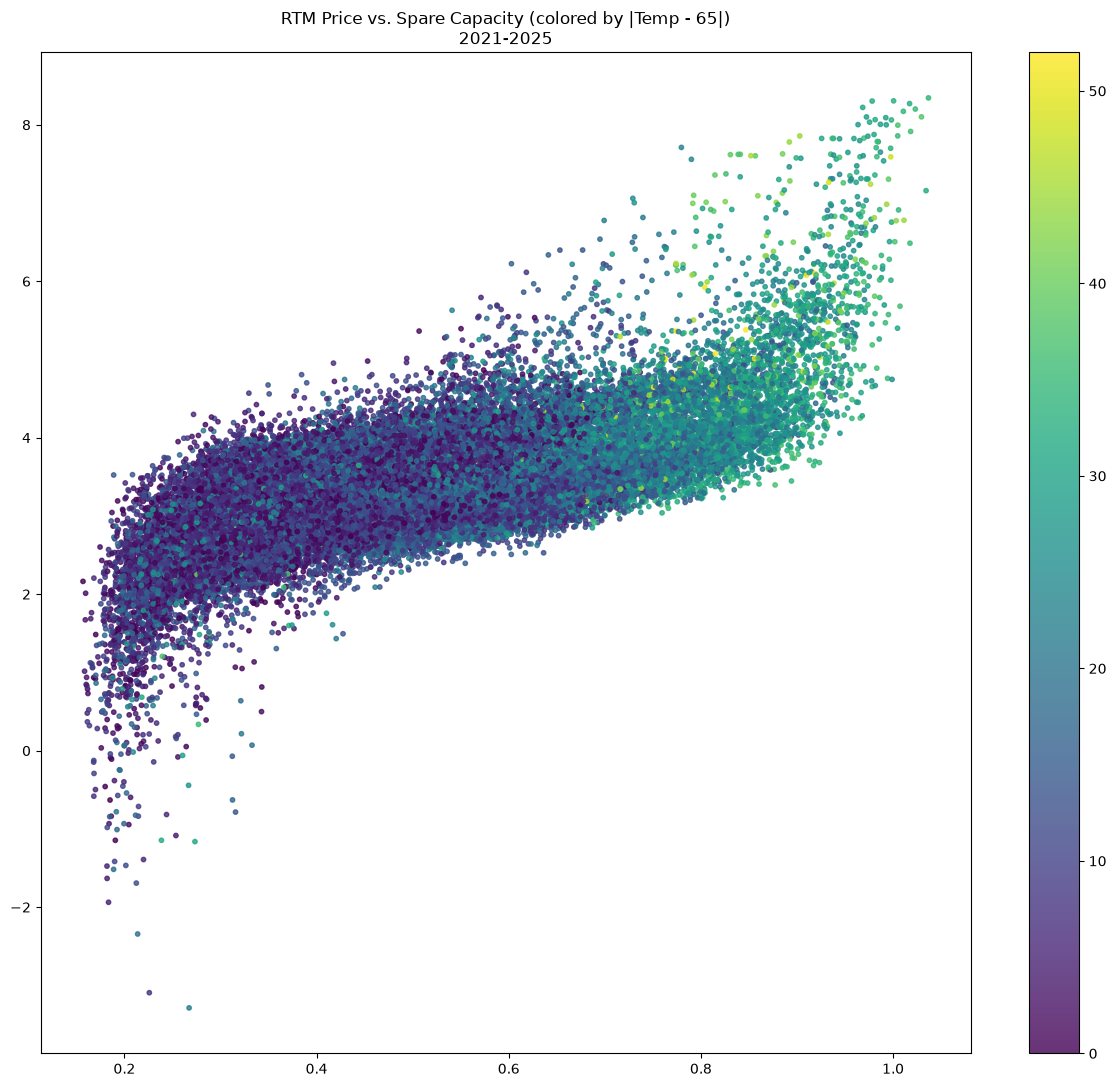

In [11]:
df = df_metric_with_temp.copy()
plt.figure(figsize=(15, 13))
plt.scatter(df['capacity'], np.log(df['rtm_price']), c=df['degree_days'], alpha=0.8, s=10)
plt.colorbar()
plt.title('RTM Price vs. Spare Capacity (colored by |Temp - 65|)\n2021-2025')

/Users/zyliazhang/Git/ERCOT-Research/.venv/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


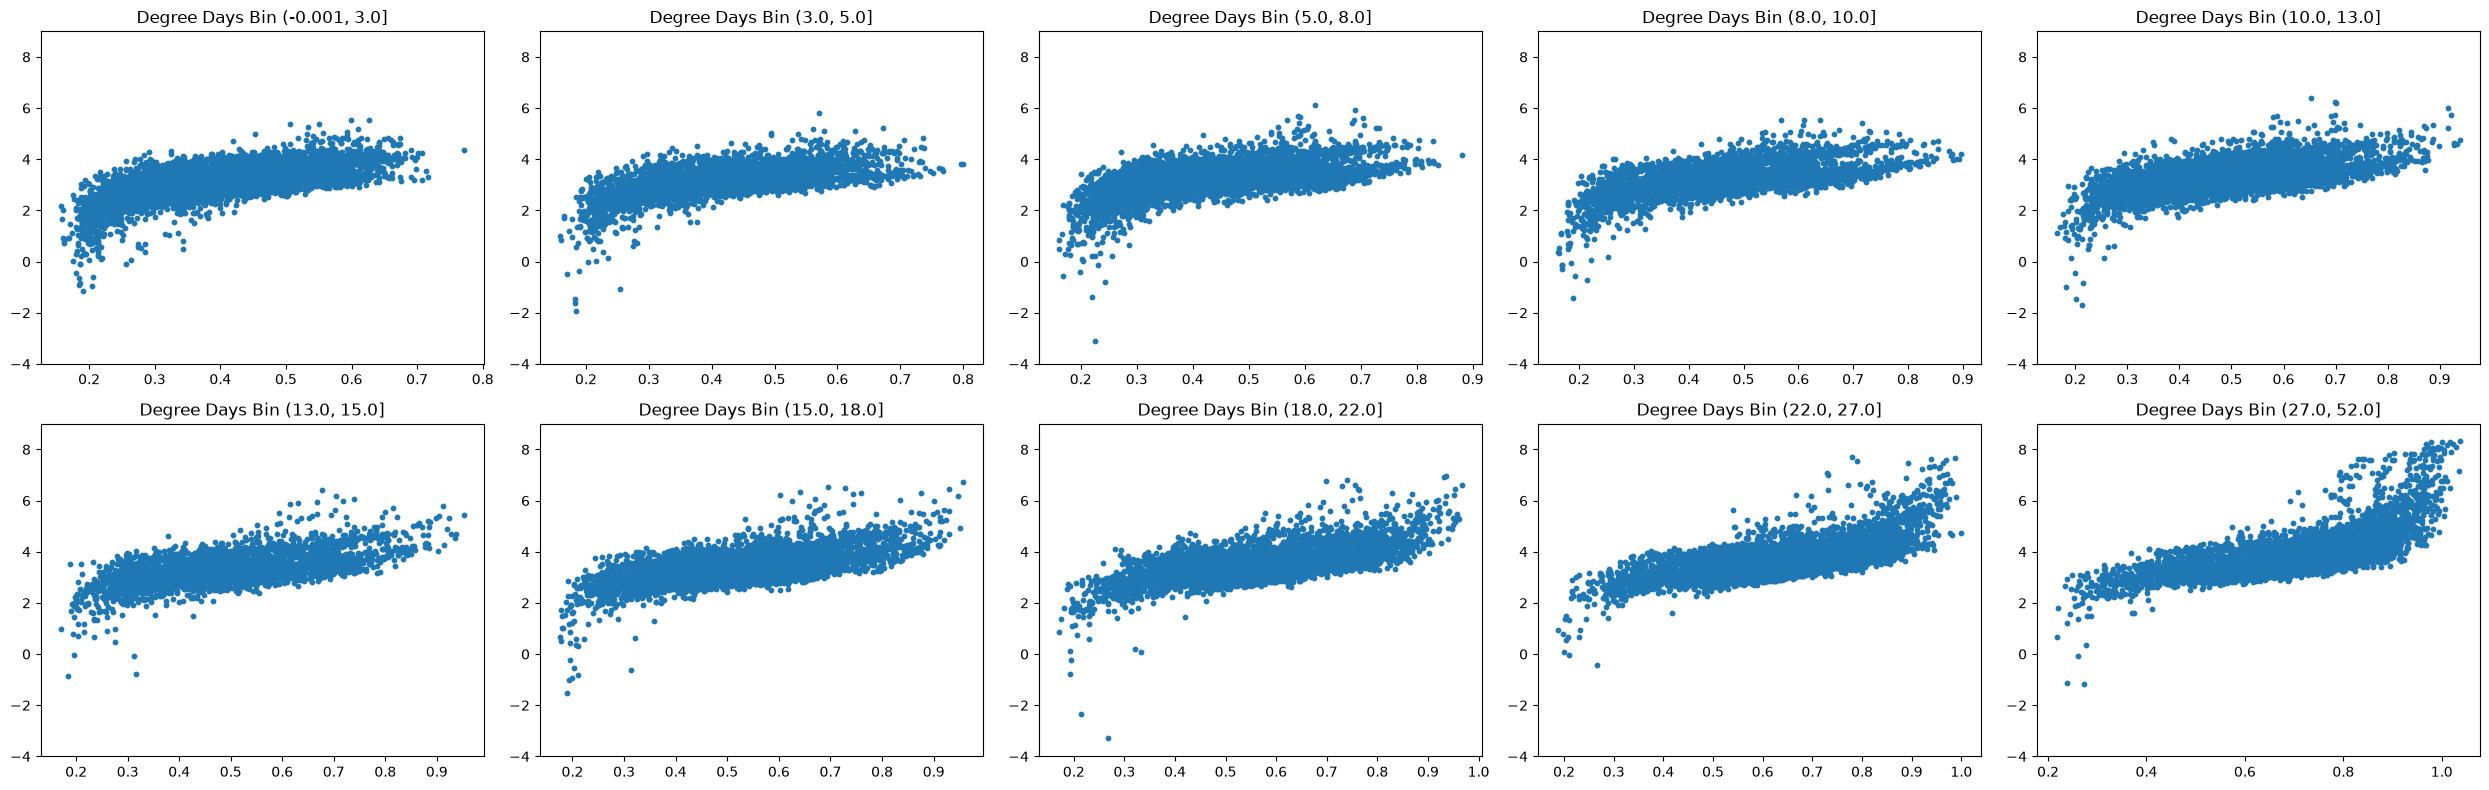

In [12]:
df = df_metric_with_temp.copy()
df = df.dropna()
df['dd_bins'] = pd.qcut(df['degree_days'], 10, duplicates='drop')
df_bins = df.sort_values('degree_days')

fig, axes = plt.subplots(2, 5, figsize=(25, 8))

for cat, ax in zip(df_bins['dd_bins'].unique(), axes.flat):
    df_bin = df_bins[df_bins['dd_bins'] == cat]
    ax.scatter(df_bin['capacity'], np.log(df_bin['rtm_price']), s=10)
    ax.set_title(f'Degree Days Bin {cat}')
    ax.set_ylim(-4, 9)
plt.tight_layout()
plt.show()